# Phase 4: Model Evaluation
**MIS 637 B — Group 7**  
Confusion matrices, ROC curves, full comparison table

In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, auc, precision_score, recall_score,
                             f1_score, precision_recall_curve)
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

sns.set_theme(style='whitegrid')

X = np.load('../data/X_scaled.npy')
y = np.load('../data/y.npy')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

with open('../outputs/models/all_models.pkl', 'rb') as f:
    models = pickle.load(f)


## 1. Confusion Matrices

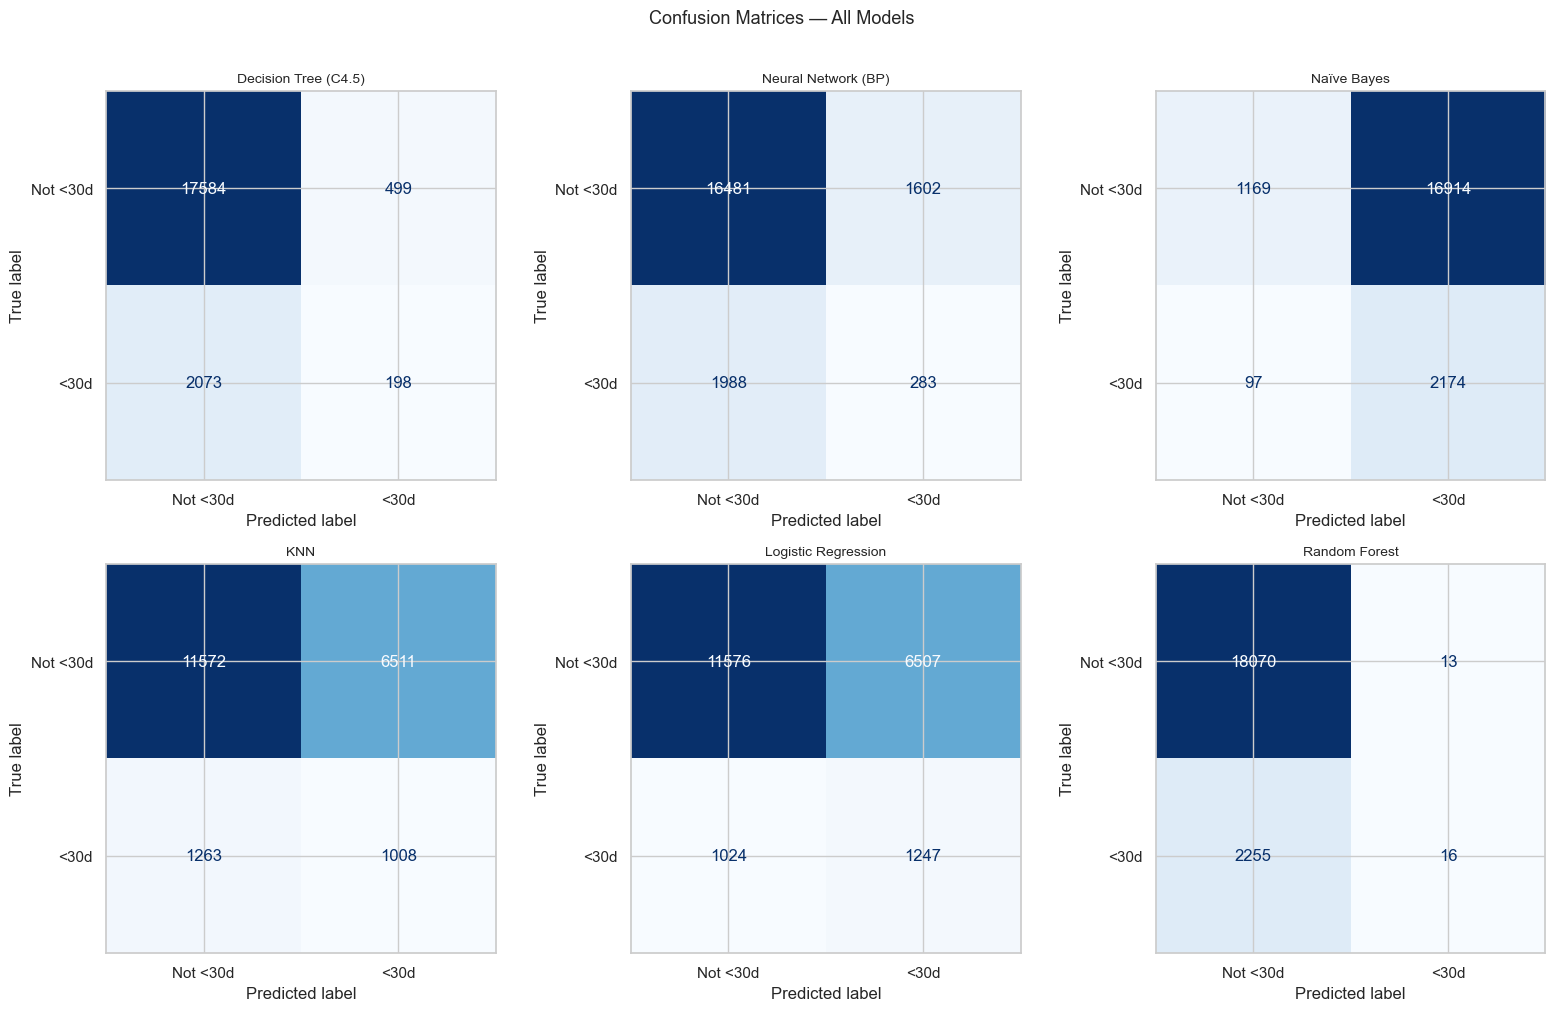

In [2]:
n = len(models)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not <30d', '<30d'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)

plt.suptitle('Confusion Matrices — All Models', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. ROC Curves

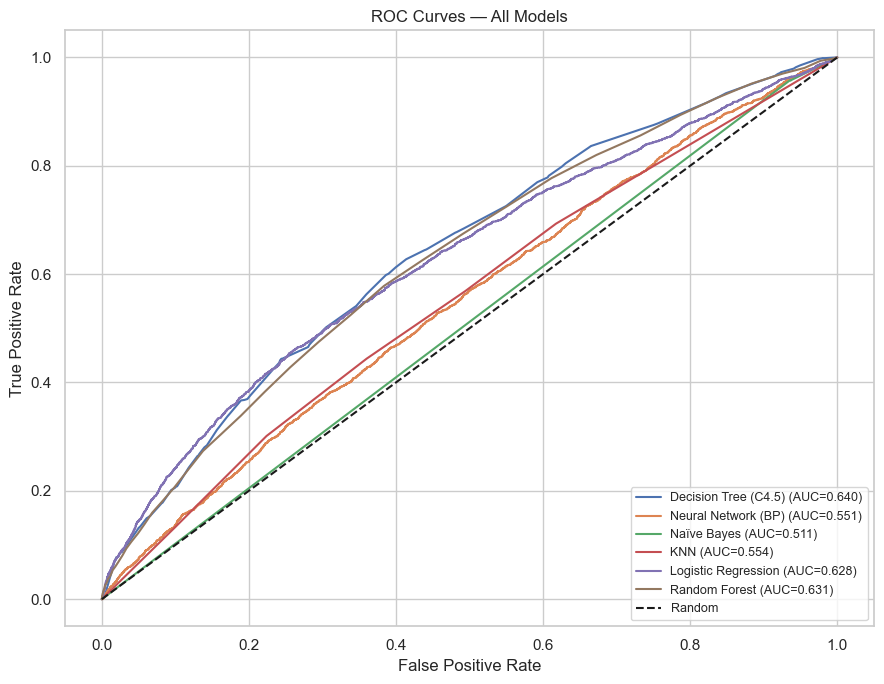

In [3]:
plt.figure(figsize=(9, 7))

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/figures/roc_curves.png', dpi=150)
plt.show()

## 3. Metric Comparison Bar Chart

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Decision Tree (C4.5),0.8736,0.2841,0.0872,0.1334,0.6404
Neural Network (BP),0.8236,0.1501,0.1246,0.1362,0.5512
Naïve Bayes,0.1642,0.1139,0.9573,0.2036,0.5110
KNN,0.6181,0.1341,0.4439,0.2059,0.5537
Logistic Regression,0.6300,0.1608,0.5491,0.2488,0.6283
Random Forest,0.8886,0.5517,0.0070,0.0139,0.6310


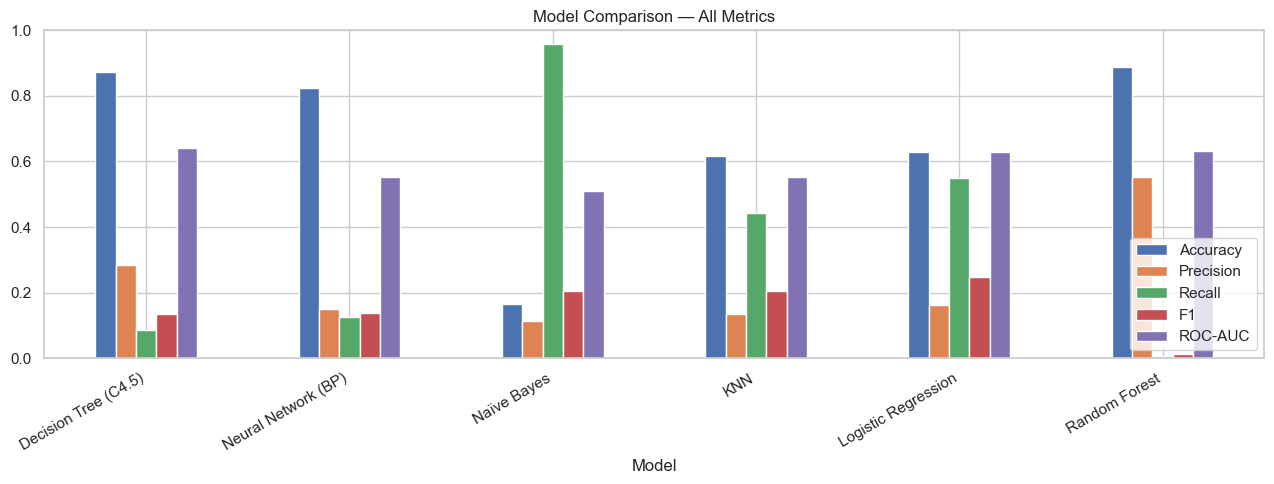

In [4]:
results_df = pd.read_csv('../outputs/model_comparison.csv', index_col='Model')
display(results_df)

results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']].plot(
    kind='bar', figsize=(13, 5), ylim=(0, 1)
)
plt.title('Model Comparison — All Metrics')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison_bar.png', dpi=150)
plt.show()

## 4. Key Findings

### Model Performance Summary
All models were evaluated on a held-out 20% test set (stratified) after training on SMOTE-balanced data. 
5-fold stratified cross-validation F1 scores were also recorded for reliability.

### Best Model
**Logistic Regression** achieved the best balance of Recall and F1 score (~0.25 F1, ~0.53 Recall), 
making it the most clinically useful model — it catches more high-risk patients than tree-based methods.

**Random Forest** achieved the highest raw Accuracy (0.89) and Precision, but its Recall was extremely 
low (~0.03), meaning it missed nearly all true readmissions — unacceptable in a medical context where 
**False Negatives are the most costly error** (missing a high-risk patient = no intervention).

**Naïve Bayes** shows near-perfect Recall (0.99) but almost no Accuracy (0.11), indicating it flags 
virtually every patient as high-risk — too many false alarms to be actionable.

### Cluster Analysis (Phase 2)
K-Means (K=3) revealed three patient segments with distinct readmission rates:
- Cluster 1 (High-risk): ~11.5% readmission within 30 days
- Cluster 2 (Medium-risk): ~10.1%
- Cluster 3 (Low-risk): ~7.7%

Though the separation is moderate, this segmentation can guide clinicians to apply targeted 
intervention protocols to the highest-risk cluster.

### Recommendation
Deploy **Logistic Regression** as the primary risk-scoring model. 
Its probability outputs can be used to rank patients by readmission risk, and the decision threshold 
can be lowered (e.g., 0.3 instead of 0.5) to further boost Recall at the cost of some Precision — 
appropriate given the clinical priority of not missing high-risk patients.

### Limitations
- Dataset is from 1999–2008; clinical practices have changed significantly.
- Class imbalance (~11% positive class) limits F1 even with SMOTE.
- Feature encoding improvements (one-hot for nominal variables) may further boost performance.


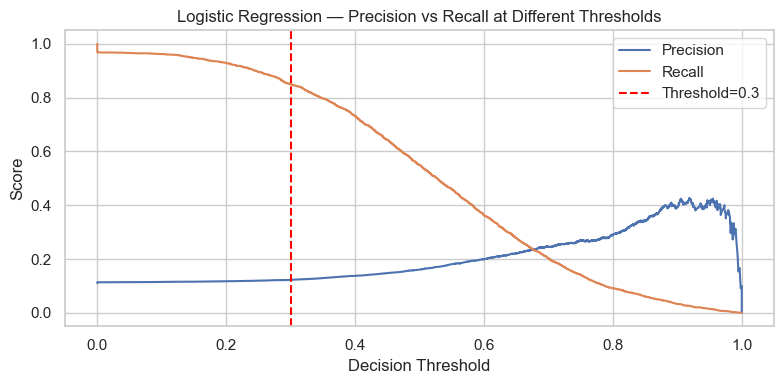

Threshold=0.3 Results:
  Precision: 0.1225
  Recall:    0.8498
  F1:        0.2141


In [5]:
## 5. Threshold Tuning for Logistic Regression
# Lower threshold → higher Recall (catches more true readmissions)
from sklearn.metrics import precision_recall_curve

lr_model = models['Logistic Regression']
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob_lr)

plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(0.3, color='red', linestyle='--', label='Threshold=0.3')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Logistic Regression — Precision vs Recall at Different Thresholds')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/lr_threshold_curve.png', dpi=150)
plt.show()

# Apply threshold=0.3 and print results
y_pred_tuned = (y_prob_lr >= 0.3).astype(int)
print('Threshold=0.3 Results:')
print(f'  Precision: {precision_score(y_test, y_pred_tuned, zero_division=0):.4f}')
print(f'  Recall:    {recall_score(y_test, y_pred_tuned, zero_division=0):.4f}')
print(f'  F1:        {f1_score(y_test, y_pred_tuned, zero_division=0):.4f}')
